In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score, precision_score,
    f1_score, classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

sns.set_style("whitegrid")

%matplotlib inline

In [64]:
df = pd.read_csv("../data/interim/bank_churn_cleaned.csv")
print("Shape:", df.shape)
display(df.head(3))
display(df.isnull().sum().sort_values(ascending=False).head(10))

Shape: (10299, 23)


,customer_id,full_name,age,gender,region,account_type,account_open_date,tenure_years,credit_score,annual_income,...,complaints_12mo,debt_to_income,digital_engagement,has_active_loan,has_credit_card,churned,annual_income_cleaned,complaints_12mo_missing,credit_score_missing,gender_missing
0,CUST-007684,Eric Flores,62,Female,Metro Manila,Checking,1990-01-01,2.2,684.0,38405,...,3.0,0.339,61.6,0,0.0,0,38405.0,0,1,0
1,CUST-003889,Mary Peterson,43,Female,Cebu,Business,1990-01-02,5.1,843.0,48383,...,0.0,0.258,71.2,0,1.0,0,48383.0,0,0,0
2,CUST-006548,Jeremy Nicholson,31,Female,Luzon,Premium,1990-01-03,0.7,759.0,108844,...,0.0,0.550,61.6,0,1.0,0,108844.0,0,0,0


num_products         357
full_name              0
customer_id            0
gender                 0
region                 0
account_type           0
age                    0
account_open_date      0
tenure_years           0
annual_income          0
dtype: int64

In [65]:
df["account_open_date"] = pd.to_datetime(df["account_open_date"], errors="coerce")
ref_date = pd.Timestamp("2024-01-01")
df["account_age_days"] = (ref_date - df["account_open_date"]).dt.days

eps = 1e-6
df["balance_income_ratio"] = df["account_balance"] / (df["annual_income_cleaned"] + eps)
df["txn_per_product"] = df["monthly_transactions"] / (df["num_products"] + 1.0)
df["complaint_txn_ratio"] = df["complaints_12mo"] / (df["monthly_transactions"] + 1.0)
df["low_engagement_flag"] = (df["digital_engagement"] < 40).astype(int)

display(df[[
    "account_age_days", "balance_income_ratio", "txn_per_product",
    "complaint_txn_ratio", "low_engagement_flag"
]].describe())


,account_age_days,balance_income_ratio,txn_per_product,complaint_txn_ratio,low_engagement_flag
count,10299.000000,10299.000000,9942.000000,10299.000000,10299.000000
mean,6276.331003,1.551465,6.316980,0.031397,0.165065
std,3460.791114,0.836183,2.651360,0.058081,0.371257
min,366.000000,0.100136,0.833333,0.000000,0.000000
25%,3285.500000,0.834153,4.250000,0.000000,0.000000
50%,6186.000000,1.551167,6.000000,0.000000,0.000000
75%,9229.500000,2.285080,8.000000,0.052632,0.000000
max,12418.000000,3.097524,17.000000,0.714286,1.000000


In [66]:
target_col = "churned"
drop_cols = [
    "churned",
    "customer_id",
    "full_name",
    "annual_income",      
    "account_open_date" 
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
y = df[target_col].astype(int)

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))

X shape: (10299, 23)
y distribution:
 churned
0    0.983785
1    0.016215
Name: proportion, dtype: float64


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train: (8239, 23) Test: (2060, 23)
Train churn rate: 0.01626410972205365
Test churn rate: 0.016019417475728156


In [68]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))


Numeric cols: 20 Categorical cols: 3


In [69]:
lr_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
        ))
])

lr_model.fit(X_train, y_train)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_pred =(lr_proba >= 0.5).astype(int)

In [70]:
def eval_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    print("\n", "="*60)
    print(name, f"(threshold={threshold})")
    print("="*60)
    print("ROC-AUC:", round(roc_auc_score(y_true, y_prob), 4))
    print("PR-AUC:", round(average_precision_score(y_true, y_prob), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("F1:", round(f1_score(y_true, y_pred), 4))
    print("\nClassification report:\n", classification_report(y_true, y_pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
eval_model("Logistic Regression", y_test, lr_proba, threshold=0.5)


Logistic Regression (threshold=0.5)
ROC-AUC: 0.7583
PR-AUC: 0.0942
Recall: 0.6061
Precision: 0.0394
F1: 0.0741

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.76      0.86      2027
           1       0.04      0.61      0.07        33

    accuracy                           0.76      2060
   macro avg       0.52      0.68      0.47      2060
weighted avg       0.98      0.76      0.85      2060

Confusion matrix:
 [[1540  487]
 [  13   20]]


,threshold,recall,precision,f1
0,0.10,1.000000,0.016940,0.033317
1,0.15,0.969697,0.018171,0.035674
2,0.20,0.909091,0.018963,0.037152
3,0.25,0.909091,0.021946,0.042857
4,0.30,0.878788,0.025174,0.048945
5,0.35,0.818182,0.028877,0.055785
6,0.40,0.787879,0.033679,0.064596
7,0.45,0.666667,0.035427,0.067278
8,0.50,0.606061,0.039448,0.074074
9,0.55,0.545455,0.044554,0.082380


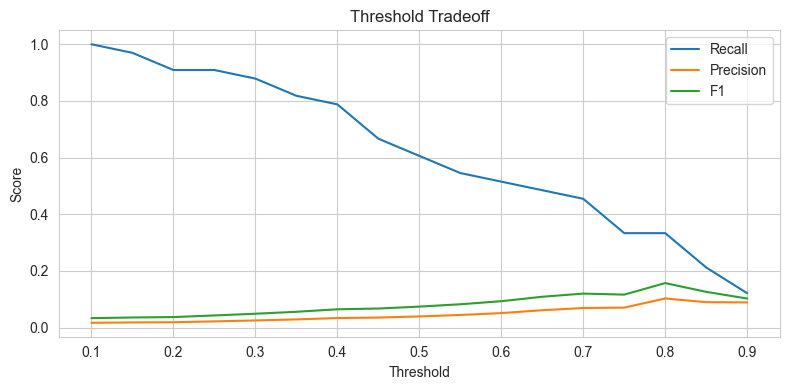

In [71]:
thresholds = np.arange(0.10, 0.91, 0.05)
rows = []

for t in thresholds:
    p = (lr_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "recall": recall_score(y_test, p),
        "precision": precision_score(y_test, p, zero_division=0),
        "f1": f1_score(y_test, p, zero_division=0)
    })

th_df = pd.DataFrame(rows)
display(th_df.sort_values("recall", ascending=False).head(10))

plt.figure(figsize=(8,4))
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.plot(th_df["threshold"], th_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tradeoff")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
rf_model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
        ))
])

rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

eval_model("Random Forest", y_test, rf_proba, threshold=0.5)



Random Forest (threshold=0.5)
ROC-AUC: 0.7971
PR-AUC: 0.1449
Recall: 0.0606
Precision: 1.0
F1: 0.1143

Classification report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2027
           1       1.00      0.06      0.11        33

    accuracy                           0.98      2060
   macro avg       0.99      0.53      0.55      2060
weighted avg       0.99      0.98      0.98      2060

Confusion matrix:
 [[2027    0]
 [  31    2]]


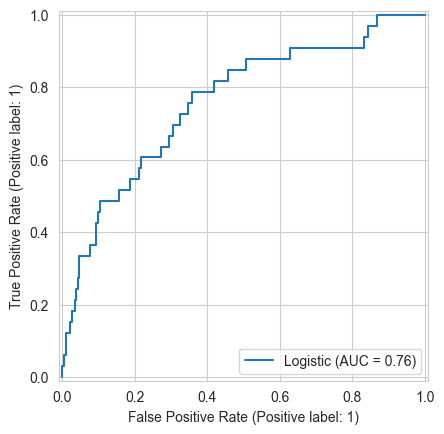

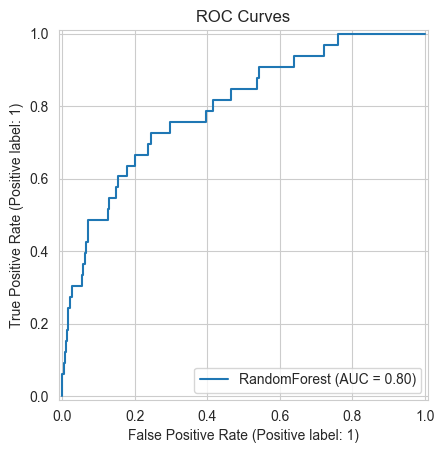

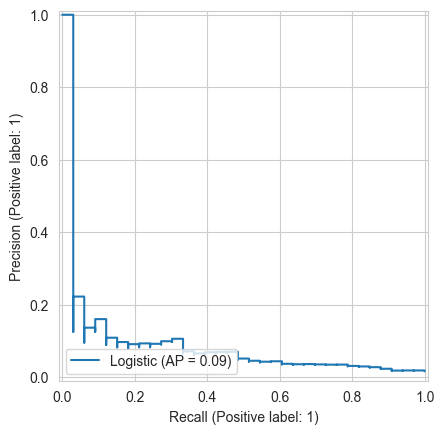

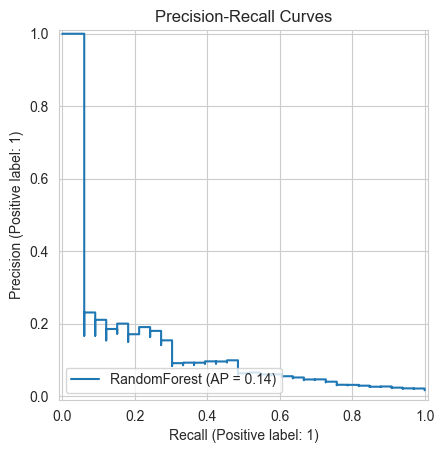

In [73]:
RocCurveDisplay.from_predictions(y_test, lr_proba, name="Logistic")
RocCurveDisplay.from_predictions(y_test, rf_proba, name="RandomForest")
plt.title("ROC Curves")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, lr_proba, name="Logistic")
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name="RandomForest")
plt.title("Precision-Recall Curves")
plt.show()

In [74]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score, precision_score, f1_score,
    classification_report, confusion_matrix
)

import numpy as np
import pandas as pd

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Churn rates -> Train:", y_train.mean(), "Val:", y_val.mean(), "Test:", y_test.mean())

models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample",
        n_jobs=-1, random_state=42
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500, min_samples_leaf=2, class_weight="balanced",
        n_jobs=-1, random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=250, learning_rate=0.05, max_depth=3, random_state=42
    ),
    "GaussianNB": GaussianNB()
}

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for name, clf in models.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", clf)
    ])

    cv_out = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    rows.append({
        "model": name,
        "cv_roc_auc_mean": cv_out["test_roc_auc"].mean(),
        "cv_pr_auc_mean": cv_out["test_pr_auc"].mean(),
        "cv_recall_mean": cv_out["test_recall"].mean(),
        "cv_precision_mean": cv_out["test_precision"].mean(),
        "cv_f1_mean": cv_out["test_f1"].mean()
    })

cv_df = pd.DataFrame(rows).sort_values("cv_pr_auc_mean", ascending=False)
display(cv_df)

best_model_name = cv_df.iloc[0]["model"]
best_clf = models[best_model_name]

best_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", best_clf)
])

best_pipe.fit(X_train, y_train)
val_proba = best_pipe.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
threshold_rows = []

for t in thresholds:
    val_pred = (val_proba >= t).astype(int)
    threshold_rows.append({
        "threshold": t,
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0)
    })

th_df = pd.DataFrame(threshold_rows)
best_t = th_df.sort_values(["f1", "recall"], ascending=False).iloc[0]["threshold"]

print("Chosen model:", best_model_name)
print("Chosen threshold from validation:", round(float(best_t), 3))
display(th_df.sort_values("f1", ascending=False).head(10))

final_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", clone(best_clf))
])
final_pipe.fit(X_train_full, y_train_full)

test_proba = final_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_t).astype(int)

print("\nFinal Test Metrics")
print("Model:", best_model_name)
print("Threshold:", round(float(best_t), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, test_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, test_proba), 4))
print("Recall:", round(recall_score(y_test, test_pred), 4))
print("Precision:", round(precision_score(y_test, test_pred, zero_division=0), 4))
print("F1:", round(f1_score(y_test, test_pred), 4))
print("\nClassification report:\n", classification_report(y_test, test_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred))

import os, joblib
os.makedirs("../models", exist_ok=True)
joblib.dump(final_pipe, "../models/best_churn_model.pkl")
print("Saved: ../models/best_churn_model.pkl")

Train: (6179, 23) Val: (2060, 23) Test: (2060, 23)
Churn rates -> Train: 0.01618384851917786 Val: 0.01650485436893204 Test: 0.016019417475728156


,model,cv_roc_auc_mean,cv_pr_auc_mean,cv_recall_mean,cv_precision_mean,cv_f1_mean
2,ExtraTrees,0.754513,0.153159,0.07,0.666667,0.124976
1,RandomForest,0.714773,0.144806,0.06,0.800000,0.110823
0,LogisticRegression,0.734660,0.091595,0.57,0.038633,0.072357
4,GaussianNB,0.722621,0.087047,0.94,0.018584,0.036447
3,GradientBoosting,0.700491,0.078298,0.04,0.350000,0.068490


Chosen model: ExtraTrees
Chosen threshold from validation: 0.34


,threshold,recall,precision,f1
30,0.35,0.117647,0.400000,0.181818
29,0.34,0.117647,0.400000,0.181818
28,0.33,0.117647,0.363636,0.177778
27,0.32,0.117647,0.307692,0.170213
26,0.31,0.117647,0.285714,0.166667
69,0.74,0.088235,1.000000,0.162162
63,0.68,0.088235,1.000000,0.162162
71,0.76,0.088235,1.000000,0.162162
68,0.73,0.088235,1.000000,0.162162
66,0.71,0.088235,1.000000,0.162162



Final Test Metrics
Model: ExtraTrees
Threshold: 0.34
ROC-AUC: 0.7083
PR-AUC: 0.1169
Recall: 0.0606
Precision: 0.2
F1: 0.093

Classification report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2027
           1       0.20      0.06      0.09        33

    accuracy                           0.98      2060
   macro avg       0.59      0.53      0.54      2060
weighted avg       0.97      0.98      0.98      2060

Confusion matrix:
 [[2019    8]
 [  31    2]]
Saved: ../models/best_churn_model.pkl


In [75]:
os.makedirs("../data/processed", exist_ok=True)

X_train.to_csv("../data/processed/X_train.csv", index=False)
X_val.to_csv("../data/processed/X_val.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)

y_train.to_csv("../data/processed/y_train.csv", index=False)
y_val.to_csv("../data/processed/y_val.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print(f"  X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

  X_train: (6179, 23), X_val: (2060, 23), X_test: (2060, 23)


In [76]:
import os
os.makedirs("../reports/figures", exist_ok=True)

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, test_proba, ax=ax, name=best_model_name)
plt.title(f"ROC Curve - {best_model_name} (Threshold: {best_t:.3f})")
plt.tight_layout()
plt.savefig("../reports/figures/01_roc_curve.png", dpi=150)
plt.close()

# PR curves
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=ax, name=best_model_name)
plt.title(f"Precision-Recall Curve - {best_model_name} (Threshold: {best_t:.3f})")
plt.tight_layout()
plt.savefig("../reports/figures/02_pr_curve.png", dpi=150)
plt.close()

# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
disp.plot(ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("../reports/figures/03_confusion_matrix.png", dpi=150)
plt.close()